# RetailIQ 360° — Clustering de Clientes (K-Means)
## Segmentación no supervisada para inteligencia comercial omnicanal

**Objetivo:** Identificar grupos naturales de clientes a partir de su comportamiento
de compra (Recencia · Frecuencia · Monto) usando K-Means, complementando el análisis
RFM basado en reglas con una segmentación *data-driven*.

---

**Entradas:**
- `datos/04_procesados/fact_ventas_final.csv` — 110.197 ítems de venta
- `datos/04_procesados/dim_clientes_ar.csv` — 10.000 clientes con variables demográficas

**Salida:**
- `datos/04_procesados/clustering_clientes.csv` — segmentos K-Means para Power BI

---

**Features RFM usadas en el clustering:**

| Feature | Descripción | Dirección deseable |
|---|---|---|
| `recencia` | Días desde última compra hasta 2018-08-31 | ↓ menor es mejor |
| `frecuencia` | Órdenes únicas (`DISTINCTCOUNT order_id`) | ↑ mayor es mejor |
| `monto_total` | Suma de `precio_venta_ars_real` con IPC | ↑ mayor es mejor |
| `ticket_promedio` | `monto_total / frecuencia` | ↑ mayor es mejor |

In [1]:
# Verificar e instalar librerías necesarias.
# scikit-learn puede no estar en todos los entornos Jupyter por defecto.
import subprocess
import sys

librerias = {
    'sklearn'   : 'scikit-learn>=1.8',
    'pandas'    : 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn'   : 'seaborn',
    'numpy'     : 'numpy',
}

for modulo, paquete in librerias.items():
    try:
        __import__(modulo)
        print(f"✓ {modulo} ya instalado")
    except ImportError:
        print(f"  Instalando {paquete}...", end=" ")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', paquete, '-q'])
        print("OK")

✓ sklearn ya instalado
✓ pandas ya instalado
✓ matplotlib ya instalado
✓ seaborn ya instalado
✓ numpy ya instalado


In [2]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sklearn
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

# ── Rutas del proyecto (relativas al notebook) ─────────────────────────────────────
PROC_DIR        = Path('../datos/04_procesados')
INPUT_VENTAS    = PROC_DIR / 'fact_ventas_final.csv'
INPUT_CLIENTES  = PROC_DIR / 'dim_clientes_ar.csv'
OUTPUT_CLUSTERS = PROC_DIR / 'clustering_clientes.csv'

# ── Parámetros del análisis ────────────────────────────────────────────────
SEED        = 42
K_CLUSTERS  = 4
K_MIN       = 2
K_MAX       = 10
FECHA_CORTE = pd.Timestamp('2018-08-31')  # fecha máxima del dataset
FEATURES    = ['recencia', 'frecuencia', 'monto_total', 'ticket_promedio']

# ── Paleta visual ───────────────────────────────────────────────────────
# Un color fijo por nombre de cluster para que los gráficos sean consistentes.
PALETA = {
    'Alto valor': '#1565C0',
    'Frecuente' : '#2E7D32',
    'Ocasional' : '#E65100',
    'Inactivo'  : '#757575',
}

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"Python:       {sys.version[:6]}")
print(f"Pandas:       {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print()
print(f"Parámetros configurados:")
print(f"  K clusters:   {K_CLUSTERS}  |  SEED: {SEED}")
print(f"  Fecha corte:  {FECHA_CORTE.date()}")
print(f"  Features:     {FEATURES}")

Python:       3.14.0
Pandas:       3.0.2
Scikit-learn: 1.8.0

Parámetros configurados:
  K clusters:   4  |  SEED: 42
  Fecha corte:  2018-08-31
  Features:     ['recencia', 'frecuencia', 'monto_total', 'ticket_promedio']


---
## BLOQUE 0 — Carga y validación de inputs

Se verifica que los archivos de entrada existan antes de iniciar cualquier procesamiento.
Si alguno falta, el error indica explícitamente qué notebook previo debe ejecutarse.

In [3]:
# Verificar existencia de archivos de entrada.
# Un error explícito aquí es mucho más fácil de diagnosticar que un KeyError a mitad del pipeline.
for ruta, dep in [
    (INPUT_VENTAS,   '04_ETL.ipynb'),
    (INPUT_CLIENTES, '01_creador_datos_sinteticos.ipynb o 04_ETL.ipynb'),
]:
    if not ruta.exists():
        raise FileNotFoundError(
            f"\nArchivo no encontrado: {ruta}\n"
            f"Ejecutar {dep} para generarlo."
        )
    tam_mb = ruta.stat().st_size / 1024 / 1024
    print(f"✓ {ruta.name}  ({tam_mb:.1f} MB)")

# Carga con encoding UTF-8-SIG (estándar del proyecto, necesario para tildes en Windows)
df_ventas   = pd.read_csv(INPUT_VENTAS,   encoding='utf-8-sig')
df_clientes = pd.read_csv(INPUT_CLIENTES, encoding='utf-8-sig')

print(f"\nfact_ventas_final : {df_ventas.shape[0]:,} filas x {df_ventas.shape[1]} columnas")
print(f"dim_clientes_ar   : {df_clientes.shape[0]:,} filas x {df_clientes.shape[1]} columnas")

✓ fact_ventas_final.csv  (27.7 MB)
✓ dim_clientes_ar.csv  (1.4 MB)

fact_ventas_final : 110,197 filas x 28 columnas
dim_clientes_ar   : 10,000 filas x 15 columnas


In [4]:
# Validar que las columnas clave existen en cada dataset.
cols_ventas_req   = ['ClienteID', 'order_id', 'fecha', 'precio_venta_ars_real', 'tiene_ipc']
cols_clientes_req = ['ClienteID', 'nse', 'rango_edad', 'canal_preferido', 'GeografiaID']

for col in cols_ventas_req:
    assert col in df_ventas.columns,   f"Columna '{col}' ausente en fact_ventas_final"
for col in cols_clientes_req:
    assert col in df_clientes.columns, f"Columna '{col}' ausente en dim_clientes_ar"

print("Columnas clave validadas correctamente")

# Convertir 'fecha' a datetime para calcular recencia
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])

# Normalizar 'tiene_ipc' a boolean real (los CSV pueden almacenarlo como string 'True'/'False')
df_ventas['tiene_ipc'] = df_ventas['tiene_ipc'].astype(str).str.strip() == 'True'

print(f"\nRango de fechas en fact_ventas_final:")
print(f"  Desde: {df_ventas['fecha'].min().date()}")
print(f"  Hasta: {df_ventas['fecha'].max().date()}")
print(f"  Fecha de corte para recencia: {FECHA_CORTE.date()}")
print(f"\nDistribución de tiene_ipc:")
print(df_ventas['tiene_ipc'].value_counts().to_string())

Columnas clave validadas correctamente

Rango de fechas en fact_ventas_final:
  Desde: 2016-09-15
  Hasta: 2018-08-29
  Fecha de corte para recencia: 2018-08-31

Distribución de tiene_ipc:
tiene_ipc
True     109880
False       317


---
## BLOQUE 1 — Construcción de features RFM por cliente

Se agrega `fact_ventas_final` al nivel cliente calculando las cuatro features del modelo:

- **Recencia:** días desde la última compra hasta `2018-08-31`. Cuanto menor, más activo es el cliente.
- **Frecuencia:** número de órdenes únicas (`DISTINCTCOUNT order_id`), captura lealtad.
- **Monto total:** suma de `precio_venta_ars_real` donde `tiene_ipc = True` (precios ajustados por IPC).
  Se usa solo el monto ajustado para comparar clientes con independencia de la inflación.
- **Ticket promedio:** `monto_total / frecuencia`, captura el valor por orden independientemente
  del volumen total — un cliente puede gastar mucho por visita aunque no compre seguido.

Luego se hace `LEFT JOIN` con `dim_clientes_ar` para agregar variables demográficas.

In [5]:
# Recencia: diferencia en días entre la fecha de corte y la última compra de cada cliente.
# Usamos FECHA_CORTE = 2018-08-31 (máxima del dataset) para que todos los clientes
# tengan recencia calculada en el mismo punto de referencia.
df_recencia = (
    df_ventas
    .groupby('ClienteID')['fecha']
    .max()
    .reset_index()
    .rename(columns={'fecha': 'ultima_compra'})
)
df_recencia['recencia'] = (FECHA_CORTE - df_recencia['ultima_compra']).dt.days

# Frecuencia: cantidad de órdenes únicas por cliente (DISTINCTCOUNT order_id).
df_frecuencia = (
    df_ventas
    .groupby('ClienteID')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'frecuencia'})
)

# Monto total: suma de precio ajustado por IPC.
# Se filtra tiene_ipc = True para usar solo precios deflactados (valores reales comparables).
df_monto = (
    df_ventas[df_ventas['tiene_ipc']]
    .groupby('ClienteID')['precio_venta_ars_real']
    .sum()
    .reset_index()
    .rename(columns={'precio_venta_ars_real': 'monto_total'})
)

# Combinar las tres dimensiones RFM en un único DataFrame por cliente
df_rfm = (
    df_recencia[['ClienteID', 'recencia']]
    .merge(df_frecuencia, on='ClienteID', how='left')
    .merge(df_monto,      on='ClienteID', how='left')
)

# Ticket promedio: usa np.where para evitar división por cero cuando frecuencia = 0
df_rfm['monto_total']    = df_rfm['monto_total'].fillna(0)
df_rfm['ticket_promedio'] = np.where(
    df_rfm['frecuencia'] > 0,
    df_rfm['monto_total'] / df_rfm['frecuencia'],
    0
)

print(f"Clientes con historial de compras: {len(df_rfm):,}")
print()
print("Estadísticas descriptivas de features RFM:")
display(df_rfm[FEATURES].describe().round(2))

Clientes con historial de compras: 9,999

Estadísticas descriptivas de features RFM:


,recencia,frecuencia,monto_total,ticket_promedio
count,9999.00,9999.00,9999.00,9999.00
mean,44.33,11.02,6230.84,565.24
std,40.49,3.34,3468.22,276.63
min,2.00,1.00,47.07,47.07
25%,17.00,9.00,3891.09,393.62
50%,30.00,11.00,5525.91,496.57
75%,60.00,13.00,7682.06,653.17
max,491.00,25.00,53044.06,4198.16


In [6]:
# LEFT JOIN con dim_clientes_ar para agregar variables demográficas.
# Se usa LEFT desde df_rfm para mantener solo clientes con historial de compras.
cols_demo = ['ClienteID', 'nse', 'rango_edad', 'genero', 'canal_preferido', 'GeografiaID']

df_rfm = df_rfm.merge(
    df_clientes[cols_demo],
    on='ClienteID',
    how='left'
)

print(f"Dataset RFM + demográficos: {len(df_rfm):,} clientes")
print(f"Columnas: {list(df_rfm.columns)}")
print()
print("Primeras 5 filas:")
display(df_rfm.head())

Dataset RFM + demográficos: 9,999 clientes
Columnas: ['ClienteID', 'recencia', 'frecuencia', 'monto_total', 'ticket_promedio', 'nse', 'rango_edad', 'genero', 'canal_preferido', 'GeografiaID']

Primeras 5 filas:


,ClienteID,recencia,frecuencia,monto_total,ticket_promedio,nse,rango_edad,genero,canal_preferido,GeografiaID
0,1,11,15,7215.00,481.00,D,35-44,F,Online,7
1,2,71,12,6443.77,536.98,ABC1,45-59,F,Físico,4
2,3,24,8,4109.75,513.72,D,45-59,M,Online,4
3,4,16,14,6471.22,462.23,C2,35-44,M,Online,4
4,5,15,9,3634.10,403.79,ABC1,21-29,M,Online,19


---
## BLOQUE 2 — Preprocesamiento: nulos, escalado y decisión sobre categóricas

### Manejo de nulos
Después del JOIN pueden quedar clientes con `NaN` en las features RFM si no tienen
compras registradas con `tiene_ipc = True`. Se los completa de la siguiente forma:
- `monto_total = 0`, `frecuencia = 0`, `ticket_promedio = 0`
- `recencia = max_recencia + 180` — se asume que son clientes muy inactivos

### Por qué escalar antes de K-Means
K-Means usa **distancia euclídea** para asignar puntos a centroides.
Sin escalar, las features con mayor magnitud (como `monto_total` en ARS, que puede llegar
a decenas de miles) dominarían el cálculo de distancias sobre features como `frecuencia`
(que va de 1 a ~20), haciendo que los clusters sean artificialmente moldeados por la escala.
`StandardScaler` elimina esta asimetría llevando cada feature a media 0 y desvío estándar 1.

### Variables categóricas
Se excluyen `nse` y `canal_preferido` del K-Means por dos razones:
1. La distancia euclídea no tiene sentido semántico para variables nominales codificadas como enteros.
2. El análisis post-hoc (Bloque 5) muestra la distribución de estas variables *dentro* de cada cluster,
   lo que es más informativo que incluirlas como features.

In [7]:
# Reportar nulos antes de imputar para que quede registro en el notebook.
nulos_antes = df_rfm[FEATURES].isna().sum()
if nulos_antes.sum() > 0:
    print("Nulos detectados antes de imputación:")
    print(nulos_antes[nulos_antes > 0].to_string())
else:
    print("Sin nulos en features RFM")

# Imputar: clientes sin compras IPC quedan con monto 0 y recencia = max + 180
max_rec = df_rfm['recencia'].max()
df_rfm['recencia']        = df_rfm['recencia'].fillna(max_rec + 180)
df_rfm['frecuencia']      = df_rfm['frecuencia'].fillna(0)
df_rfm['monto_total']     = df_rfm['monto_total'].fillna(0)
df_rfm['ticket_promedio'] = df_rfm['ticket_promedio'].fillna(0)

print(f"\nNulos después de imputación: {df_rfm[FEATURES].isna().sum().sum()}")
print(f"Clientes totales para clustering: {len(df_rfm):,}")

Sin nulos en features RFM

Nulos después de imputación: 0
Clientes totales para clustering: 9,999


In [8]:
# Aplicar StandardScaler sobre las features numéricas.
# El scaler se entrena solo con los datos del proyecto (sin datos externos).
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df_rfm[FEATURES])

# Verificar que el escalado fue correcto: media ≈ 0, desvío ≈ 1 por columna
df_scaled_check = pd.DataFrame(X_scaled, columns=FEATURES)
print("Verificación post-escalado (media y desvío por feature):")
print(df_scaled_check.agg(['mean', 'std']).round(4).to_string())

Verificación post-escalado (media y desvío por feature):
      recencia  frecuencia  monto_total  ticket_promedio
mean      0.00        0.00        -0.00             0.00
std       1.00        1.00         1.00             1.00


---
## BLOQUE 3 — Determinación del número óptimo de clusters

Se usan dos métodos complementarios:

- **Método del codo (Elbow):** grafica la inercia (suma de distancias cuadráticas al centroide)
  para cada k. El punto donde la reducción se aplana forma un "codo" — agregar más clusters
  después de ese punto no mejora significativamente la compactación.

- **Silhouette Score:** mide qué tan bien separado está cada punto de su propio cluster
  respecto de los clusters vecinos. Varía entre −1 (mal asignado) y +1 (bien separado).
  Se busca el k con el **score más alto**.

**¿Por qué k = 4?**
Elegimos k = 4 para alinear el análisis con los cuatro segmentos RFM del proyecto
(Campeón / Leal / En riesgo / Perdido), permitiendo comparar una segmentación basada en
reglas fijas con una segmentación aprendida automáticamente de los datos.

In [9]:
# Calcular inercia y Silhouette Score para k entre K_MIN y K_MAX.
# n_init=10 repite el algoritmo 10 veces con centroide aleatorios distintos
# y toma el mejor resultado — reduce la probabilidad de mínimos locales.
inertias    = []
silhouettes = []
k_range     = range(K_MIN, K_MAX + 1)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEED)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_, random_state=SEED))
    print(f"  k={k:2d}  |  inercia={km.inertia_:10.1f}  |  silhouette={silhouettes[-1]:.4f}")

print()
print(f"k elegido: {K_CLUSTERS} (ver justificación en celda anterior)")

  k= 2  |  inercia=   28008.6  |  silhouette=0.3155
  k= 3  |  inercia=   21753.1  |  silhouette=0.3289
  k= 4  |  inercia=   16834.8  |  silhouette=0.3097
  k= 5  |  inercia=   14902.1  |  silhouette=0.3074
  k= 6  |  inercia=   13121.2  |  silhouette=0.2846
  k= 7  |  inercia=   11986.4  |  silhouette=0.2556
  k= 8  |  inercia=   10895.5  |  silhouette=0.2627
  k= 9  |  inercia=   10101.6  |  silhouette=0.2623
  k=10  |  inercia=    9447.6  |  silhouette=0.2629

k elegido: 4 (ver justificación en celda anterior)


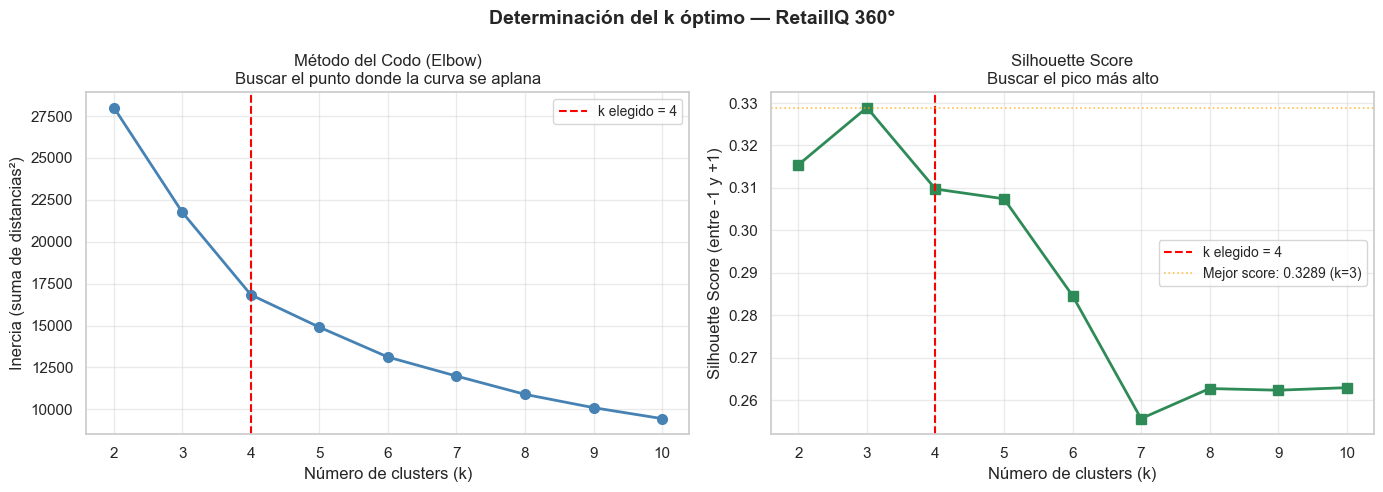

Guardado: clustering_elbow_silhouette.png


In [10]:
# Gráfico combinado: Elbow (inercia) + Silhouette Score.
# Dos subplots en la misma figura para facilitar la lectura comparativa.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Elbow ────────────────────────────────────────────────────────────────
ax1.plot(list(k_range), inertias, marker='o', linewidth=2, color='steelblue', markersize=7)
ax1.axvline(x=K_CLUSTERS, color='red', linestyle='--', linewidth=1.5, label=f'k elegido = {K_CLUSTERS}')
ax1.set_title('Método del Codo (Elbow)\nBuscar el punto donde la curva se aplana', fontsize=12)
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia (suma de distancias²)')
ax1.set_xticks(list(k_range))
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.4)

# ── Silhouette ────────────────────────────────────────────────────────────
ax2.plot(list(k_range), silhouettes, marker='s', linewidth=2, color='seagreen', markersize=7)
ax2.axvline(x=K_CLUSTERS, color='red', linestyle='--', linewidth=1.5, label=f'k elegido = {K_CLUSTERS}')
ax2.axhline(y=max(silhouettes), color='orange', linestyle=':', linewidth=1.2, alpha=0.7,
            label=f'Mejor score: {max(silhouettes):.4f} (k={silhouettes.index(max(silhouettes))+K_MIN})')
ax2.set_title('Silhouette Score\nBuscar el pico más alto', fontsize=12)
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Silhouette Score (entre -1 y +1)')
ax2.set_xticks(list(k_range))
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.4)

fig.suptitle('Determinación del k óptimo — RetailIQ 360°', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROC_DIR / 'clustering_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado: clustering_elbow_silhouette.png")

---
## BLOQUE 4 — Entrenamiento K-Means (k = 4)

Se entrena el modelo final con k = 4 y `random_state = 42` para reproducibilidad.

Los clusters se **nombran automáticamente** analizando los centroides en el espacio original
(antes del escalado), aplicando estas reglas en orden:
1. **Inactivo** → el cluster con mayor recencia (días desde última compra más altos)
2. **Alto valor** → el de mayor `monto_total` entre los restantes
3. **Frecuente** → el de mayor `frecuencia` entre los restantes
4. **Ocasional** → el que queda

In [11]:
# Entrenar K-Means final con k=4 y SEED=42.
# init='k-means++' mejora la convergencia eligiendo centroides iniciales distantes entre sí.
km_final = KMeans(
    n_clusters=K_CLUSTERS,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=SEED
)
km_final.fit(X_scaled)

df_rfm['cluster_id'] = km_final.labels_

print("Distribución inicial de clientes por cluster (IDs numéricos):")
print(df_rfm['cluster_id'].value_counts().sort_index().to_string())

# Centroides en el espacio escalado (para referencia técnica)
df_centroides_scaled = pd.DataFrame(
    km_final.cluster_centers_,
    columns=FEATURES
).round(4)
df_centroides_scaled.index.name = 'cluster_id'
print("\nCentroides (espacio escalado):")
display(df_centroides_scaled)

Distribución inicial de clientes por cluster (IDs numéricos):
cluster_id
0    1404
1     958
2    4352
3    3285

Centroides (espacio escalado):


,recencia,frecuencia,monto_total,ticket_promedio
cluster_id,,,,
0,1.94,-0.76,-0.61,-0.27
1,-0.17,0.13,1.98,2.24
2,-0.32,-0.52,-0.57,-0.36
3,-0.36,0.98,0.44,-0.06


In [12]:
# Calcular medias en el espacio ORIGINAL (no escalado) para interpretar los clusters.
stats_raw = df_rfm.groupby('cluster_id')[FEATURES].mean()

# Regla 1: Inactivo = mayor recencia (más días desde la última compra)
cluster_inactivo   = int(stats_raw['recencia'].idxmax())

# Regla 2: Alto valor = mayor monto_total entre los clusters restantes
restantes          = [c for c in stats_raw.index if c != cluster_inactivo]
cluster_alto_valor = int(stats_raw.loc[restantes, 'monto_total'].idxmax())

# Regla 3: Frecuente = mayor frecuencia entre los dos clusters restantes
restantes2         = [c for c in restantes if c != cluster_alto_valor]
cluster_frecuente  = int(stats_raw.loc[restantes2, 'frecuencia'].idxmax())

# Regla 4: Ocasional = el que queda
cluster_ocasional  = [c for c in restantes2 if c != cluster_frecuente][0]

NOMBRES_CLUSTER = {
    cluster_inactivo  : 'Inactivo',
    cluster_alto_valor: 'Alto valor',
    cluster_frecuente : 'Frecuente',
    cluster_ocasional : 'Ocasional',
}

df_rfm['cluster_nombre'] = df_rfm['cluster_id'].map(NOMBRES_CLUSTER)

print("Asignación automática de nombres:")
for cid, nombre in sorted(NOMBRES_CLUSTER.items()):
    n = (df_rfm['cluster_id'] == cid).sum()
    print(f"  cluster_id={cid}  →  {nombre:<12}  ({n:,} clientes)")

print("\nCentroides en escala original:")
display(stats_raw.rename(index=NOMBRES_CLUSTER).round(2))

Asignación automática de nombres:
  cluster_id=0  →  Inactivo      (1,404 clientes)
  cluster_id=1  →  Alto valor    (958 clientes)
  cluster_id=2  →  Ocasional     (4,352 clientes)
  cluster_id=3  →  Frecuente     (3,285 clientes)

Centroides en escala original:


,recencia,frecuencia,monto_total,ticket_promedio
cluster_id,,,,
Inactivo,122.73,8.47,4115.09,489.93
Alto valor,37.38,11.44,13087.45,1185.60
Ocasional,31.42,9.28,4246.54,464.72
Frecuente,29.96,14.30,7764.35,549.69


---
## BLOQUE 5 — Análisis de clusters

Se analiza el perfil de cada cluster desde tres ángulos:
1. **Estadísticas descriptivas** de las features RFM (media, mediana, desvío)
2. **Distribución demográfica** por NSE y canal preferido
3. **Comparación metodológica** con la segmentación RFM basada en reglas

In [13]:
# ── 5a: Estadísticas descriptivas por cluster ──────────────────────────────
print("=" * 60)
print("  PERFIL DE CLUSTERS — Estadísticas por feature RFM")
print("=" * 60)

ORDEN_NOMBRES = ['Alto valor', 'Frecuente', 'Ocasional', 'Inactivo']

stats_desc = (
    df_rfm
    .groupby('cluster_nombre')[FEATURES]
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .loc[ORDEN_NOMBRES]
)
display(stats_desc.round(2))

# Tabla resumen compacta para interpretar el perfil de cada cluster
print("\nResumen interpretativo (media por cluster):")
resumen = (
    df_rfm
    .groupby('cluster_nombre')[FEATURES]
    .mean()
    .loc[ORDEN_NOMBRES]
    .round(1)
)
resumen['n_clientes'] = df_rfm.groupby('cluster_nombre').size().loc[ORDEN_NOMBRES]
display(resumen)

  PERFIL DE CLUSTERS — Estadísticas por feature RFM


recencia                       frecuencia                      \
                   mean median   std min  max       mean median  std min max   
cluster_nombre                                                                 
Alto valor        37.38  27.00 29.04   2  197      11.44  11.00 3.31   3  25   
Frecuente         29.96  24.00 21.34   2  122      14.30  14.00 2.25  10  25   
Ocasional         31.42  27.00 18.88   2   84       9.28   9.00 1.98   2  14   
Inactivo         122.73 113.00 41.88  70  491       8.47   8.00 2.64   1  17   

               monto_total                                   ticket_promedio  \
                      mean   median     std     min      max            mean   
cluster_nombre                                                                 
Alto valor        13087.45 12249.68 4342.16 4114.91 53044.06         1185.60   
Frecuente          7764.35  7463.81 1994.21 3136.78 17265.33          549.69   
Ocasional          4246.54  4205.64 1368.25  532.64  8116.45          464.72   
Inactivo           4115.09  3924.26 1855.05   47.07 10447.18          489.93   

                                              
                median    std    min     max  
cluster_nombre                                
Alto valor     1069.00 378.26 819.59 4198.16  
Frecuente       534.95 137.76 209.12  877.33  
Ocasional       437.50 147.13 133.16 1142.70  
Inactivo        460.60 189.24  47.07 1492.45


Resumen interpretativo (media por cluster):


,recencia,frecuencia,monto_total,ticket_promedio,n_clientes
cluster_nombre,,,,,
Alto valor,37.40,11.40,13087.40,1185.60,958
Frecuente,30.00,14.30,7764.40,549.70,3285
Ocasional,31.40,9.30,4246.50,464.70,4352
Inactivo,122.70,8.50,4115.10,489.90,1404


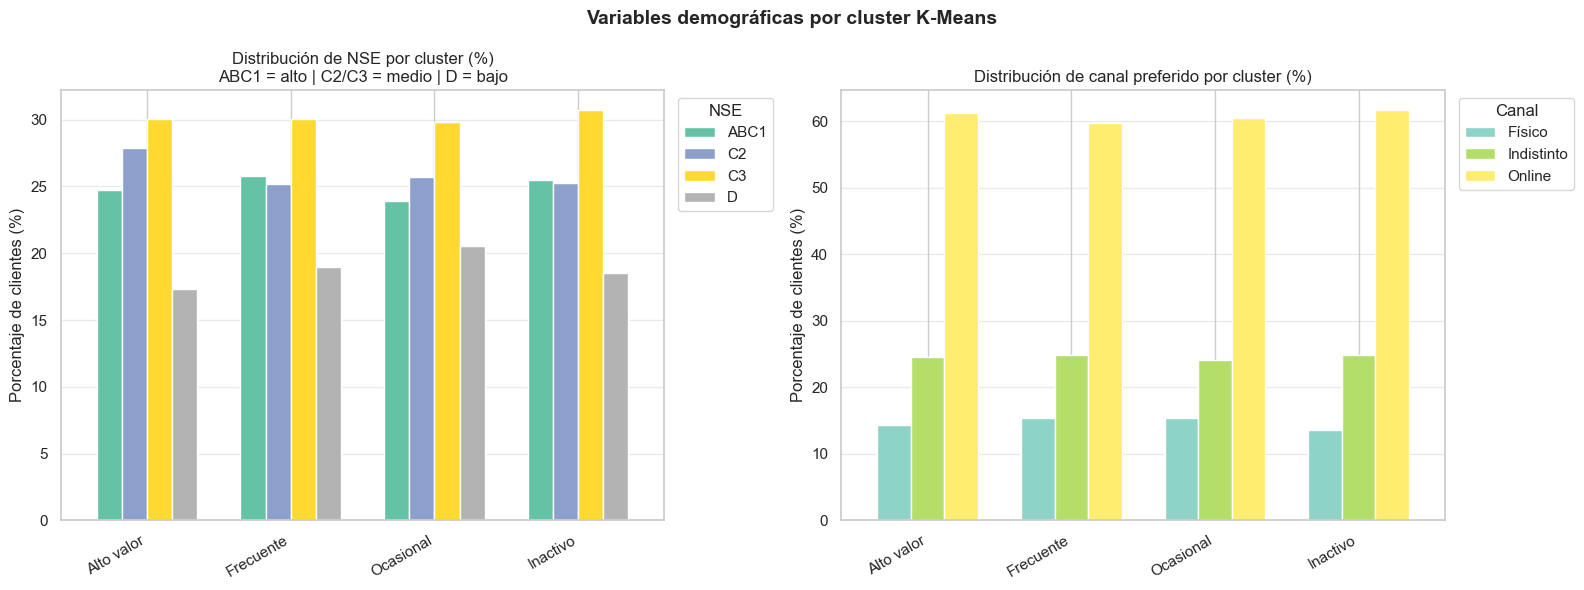

In [14]:
# ── 5b: Distribución de NSE y canal preferido por cluster ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# NSE por cluster
nse_ct = (
    df_rfm
    .groupby(['cluster_nombre', 'nse'])
    .size()
    .unstack(fill_value=0)
    .loc[ORDEN_NOMBRES]
)
nse_pct = nse_ct.div(nse_ct.sum(axis=1), axis=0) * 100
nse_pct.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.7)
axes[0].set_title('Distribución de NSE por cluster (%)\n'
                  'ABC1 = alto | C2/C3 = medio | D = bajo', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Porcentaje de clientes (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(title='NSE', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].grid(axis='y', alpha=0.4)

# Canal preferido por cluster
canal_ct = (
    df_rfm
    .groupby(['cluster_nombre', 'canal_preferido'])
    .size()
    .unstack(fill_value=0)
    .loc[ORDEN_NOMBRES]
)
canal_pct = canal_ct.div(canal_ct.sum(axis=1), axis=0) * 100
canal_pct.plot(kind='bar', ax=axes[1], colormap='Set3', edgecolor='white', width=0.7)
axes[1].set_title('Distribución de canal preferido por cluster (%)', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Porcentaje de clientes (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].legend(title='Canal', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].grid(axis='y', alpha=0.4)

fig.suptitle('Variables demográficas por cluster K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROC_DIR / 'clustering_demo_por_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── 5c: Comparación conceptual con segmentos RFM ────────────────────────────
#
# DIFERENCIA METODOLÓGICA CLAVE (aporte académico del análisis):
# ─────────────────────────────────────────────────────────────────
# RFM con REGLAS FIJAS:
#   Asigna segmentos predefinidos (Campeón / Leal / En riesgo / Perdido)
#   aplicando umbrales manuales en recencia, frecuencia y monto.
#   Es interpretable y controlable, pero los umbrales son arbitrarios
#   y no reflejan necesariamente la estructura real de los datos.
#
# K-MEANS (aprendizaje no supervisado):
#   Descubre grupos NATURALES minimizando la distancia intra-cluster.
#   No necesita umbrales: los límites emergen directamente de los datos.
#   Los clusters pueden tener cualquier forma y tamaño — son empíricos.
#   El trade-off es que los nombres ('Alto valor', 'Inactivo') los asigna
#   el analista POST-HOC interpretando los centroides.
#
# En la práctica ambos enfoques se complementan:
#   RFM da control y explicabilidad al negocio.
#   K-Means valida (o cuestiona) si los umbrales RFM son razonables.
#   Si los clusters K-Means coinciden con los segmentos RFM, los umbrales
#   elegidos están bien calibrados con la distribución real de clientes.

# Verificar si la columna segmento_rfm tiene datos en dim_clientes_ar
tiene_rfm = 'segmento_rfm' in df_rfm.columns and df_rfm['segmento_rfm'].notna().any()

if tiene_rfm:
    print("Crosstab: cluster K-Means vs segmento RFM")
    ct = pd.crosstab(
        df_rfm['cluster_nombre'],
        df_rfm['segmento_rfm'],
        normalize='index'
    ) * 100
    display(ct.round(1))
else:
    print("La columna segmento_rfm no contiene datos aún en dim_clientes_ar.")
    print("Comparación conceptual basada en los centroides K-Means:")
    print()
    comparacion = pd.DataFrame({
        'Cluster K-Means'  : ['Alto valor',   'Frecuente',    'Ocasional',    'Inactivo'],
        'Equivalente RFM'  : ['Campeón',       'Leal',         'En riesgo',    'Perdido'],
        'Coincidencia esperada': [
            'Alta: recencia baja + monto alto = Campeón',
            'Alta: frecuencia alta + monto moderado = Leal',
            'Moderada: compras ocasionales = En riesgo',
            'Alta: recencia muy alta + actividad baja = Perdido',
        ],
        'Diferencia clave' : [
            'K-Means: umbral automático; RFM: umbral manual',
            'K-Means: agrupa por distancia; RFM: por score',
            'K-Means puede capturar clientes RFM mixtos',
            'K-Means puede separar inactivos recientes vs históricos',
        ]
    })
    display(comparacion)

La columna segmento_rfm no contiene datos aún en dim_clientes_ar.
Comparación conceptual basada en los centroides K-Means:



,Cluster K-Means,Equivalente RFM,Coincidencia esperada,Diferencia clave
0,Alto valor,Campeón,Alta: recencia baja + monto alto = Campeón,K-Means: umbral automático; RFM: umbral manual
1,Frecuente,Leal,Alta: frecuencia alta + monto moderado = Leal,K-Means: agrupa por distancia; RFM: por score
2,Ocasional,En riesgo,Moderada: compras ocasionales = En riesgo,K-Means puede capturar clientes RFM mixtos
3,Inactivo,Perdido,Alta: recencia muy alta + actividad baja = Per...,K-Means puede separar inactivos recientes vs h...


---
## BLOQUE 6 — Visualizaciones

Cuatro gráficos que muestran la estructura de los clusters desde distintos ángulos:
1. Scatter recencia vs monto (dimensión valor + actividad temporal)
2. Scatter frecuencia vs monto (dimensión lealtad + valor)
3. Heatmap de centroides normalizados (perfil comparativo)
4. Distribución de clientes por cluster (tamaño relativo)

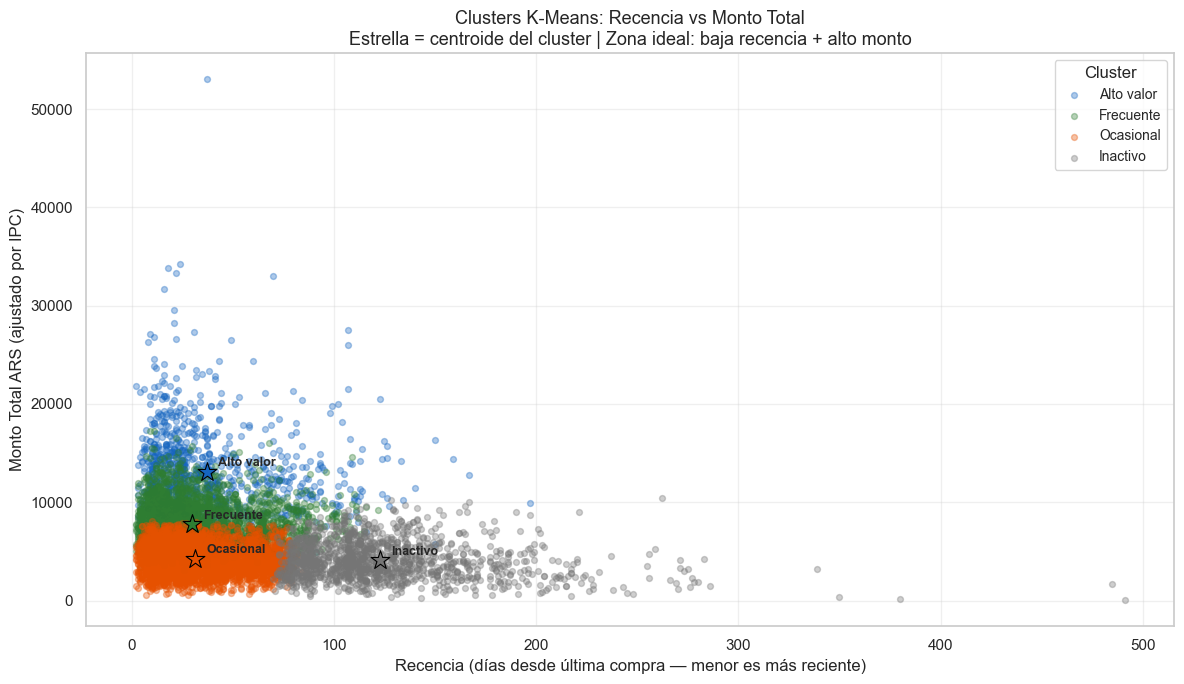

In [16]:
# ── 6a: Scatter recencia vs monto_total ─────────────────────────────────────
# Muestra la separación entre clientes activos-valiosos (abajo-derecha)
# y clientes inactivos-de-bajo-valor (arriba-izquierda).
fig, ax = plt.subplots(figsize=(12, 7))

for nombre in ORDEN_NOMBRES:
    sub = df_rfm[df_rfm['cluster_nombre'] == nombre]
    ax.scatter(
        sub['recencia'],
        sub['monto_total'],
        alpha=0.35,
        s=18,
        color=PALETA[nombre],
        label=nombre
    )

# Marcar centroides
for cid, nombre in NOMBRES_CLUSTER.items():
    cx = df_rfm[df_rfm['cluster_id'] == cid]['recencia'].mean()
    cy = df_rfm[df_rfm['cluster_id'] == cid]['monto_total'].mean()
    ax.scatter(cx, cy, color=PALETA[nombre], s=200, marker='*',
               edgecolors='black', linewidths=0.8, zorder=5)
    ax.annotate(nombre, (cx, cy), textcoords='offset points',
                xytext=(8, 4), fontsize=9, fontweight='bold')

ax.set_title('Clusters K-Means: Recencia vs Monto Total\n'
             'Estrella = centroide del cluster | Zona ideal: baja recencia + alto monto',
             fontsize=13)
ax.set_xlabel('Recencia (días desde última compra — menor es más reciente)')
ax.set_ylabel('Monto Total ARS (ajustado por IPC)')
ax.legend(title='Cluster', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROC_DIR / 'clustering_scatter_recencia_monto.png', dpi=150, bbox_inches='tight')
plt.show()

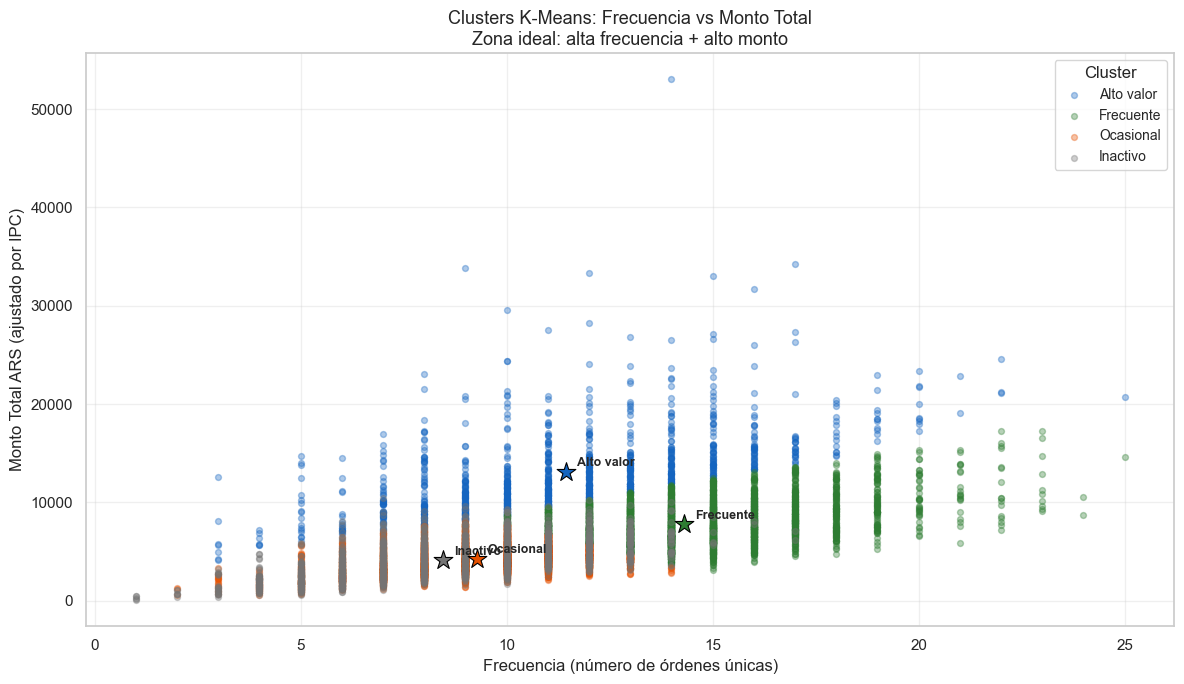

In [17]:
# ── 6b: Scatter frecuencia vs monto_total ────────────────────────────────────
# Muestra la separación en el eje de lealtad (frecuencia) vs valor económico.
fig, ax = plt.subplots(figsize=(12, 7))

for nombre in ORDEN_NOMBRES:
    sub = df_rfm[df_rfm['cluster_nombre'] == nombre]
    ax.scatter(
        sub['frecuencia'],
        sub['monto_total'],
        alpha=0.35,
        s=18,
        color=PALETA[nombre],
        label=nombre
    )

# Centroides
for cid, nombre in NOMBRES_CLUSTER.items():
    cx = df_rfm[df_rfm['cluster_id'] == cid]['frecuencia'].mean()
    cy = df_rfm[df_rfm['cluster_id'] == cid]['monto_total'].mean()
    ax.scatter(cx, cy, color=PALETA[nombre], s=200, marker='*',
               edgecolors='black', linewidths=0.8, zorder=5)
    ax.annotate(nombre, (cx, cy), textcoords='offset points',
                xytext=(8, 4), fontsize=9, fontweight='bold')

ax.set_title('Clusters K-Means: Frecuencia vs Monto Total\n'
             'Zona ideal: alta frecuencia + alto monto', fontsize=13)
ax.set_xlabel('Frecuencia (número de órdenes únicas)')
ax.set_ylabel('Monto Total ARS (ajustado por IPC)')
ax.legend(title='Cluster', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROC_DIR / 'clustering_scatter_frecuencia_monto.png', dpi=150, bbox_inches='tight')
plt.show()

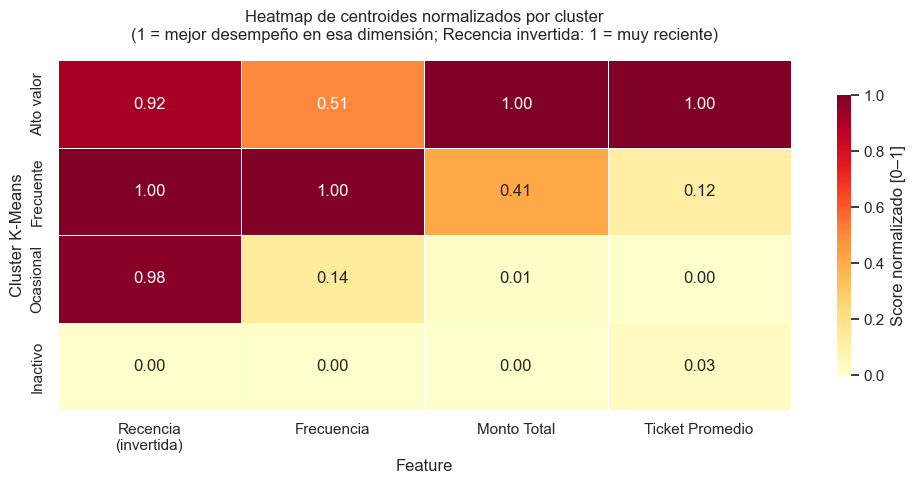

In [18]:
# ── 6c: Heatmap de centroides normalizados ────────────────────────────────────
# Se normaliza cada feature al rango [0, 1] con MinMax para que el heatmap sea
# visualmente comparable entre features de diferente magnitud.
# ATENCIÓN: para recencia, un valor alto es MALO (más días de inactividad),
# por eso se invierte antes de normalizar.

centroides_orig = (
    df_rfm
    .groupby('cluster_nombre')[FEATURES]
    .mean()
    .loc[ORDEN_NOMBRES]
)

# Invertir recencia: recencia_inv = max - recencia (ahora alto = más reciente = mejor)
centroides_norm = centroides_orig.copy()
centroides_norm['recencia'] = centroides_norm['recencia'].max() - centroides_norm['recencia']

# Normalizar al rango [0, 1] por columna
for col in FEATURES:
    rng = centroides_norm[col].max() - centroides_norm[col].min()
    if rng > 0:
        centroides_norm[col] = (centroides_norm[col] - centroides_norm[col].min()) / rng

centroides_norm = centroides_norm.rename(columns={
    'recencia'        : 'Recencia\n(invertida)',
    'frecuencia'      : 'Frecuencia',
    'monto_total'     : 'Monto Total',
    'ticket_promedio' : 'Ticket Promedio',
})

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    centroides_norm,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Score normalizado [0–1]', 'shrink': 0.8},
    vmin=0, vmax=1
)
ax.set_title(
    'Heatmap de centroides normalizados por cluster\n'
    '(1 = mejor desempeño en esa dimensión; Recencia invertida: 1 = muy reciente)',
    fontsize=12, pad=15
)
ax.set_ylabel('Cluster K-Means')
ax.set_xlabel('Feature')
plt.tight_layout()
plt.savefig(PROC_DIR / 'clustering_heatmap_centroides.png', dpi=150, bbox_inches='tight')
plt.show()

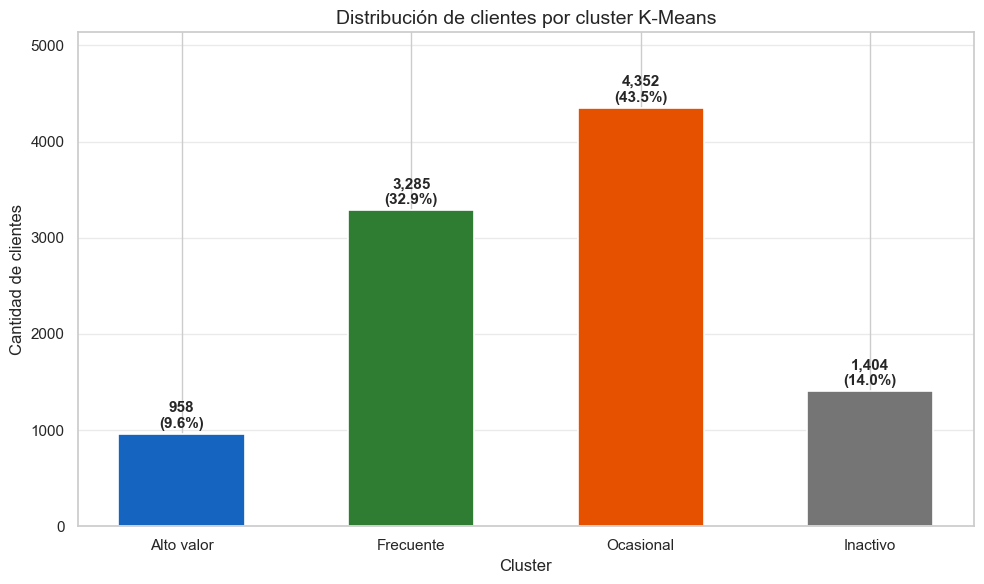

Clientes por cluster:
  Alto valor    958  (9.6%)
  Frecuente     3,285  (32.9%)
  Ocasional     4,352  (43.5%)
  Inactivo      1,404  (14.0%)


In [19]:
# ── 6d: Distribución de clientes por cluster ─────────────────────────────────
conteo_clusters = (
    df_rfm['cluster_nombre']
    .value_counts()
    .reindex(ORDEN_NOMBRES)
)
pct_clusters = conteo_clusters / conteo_clusters.sum() * 100

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    conteo_clusters.index,
    conteo_clusters.values,
    color=[PALETA[n] for n in conteo_clusters.index],
    edgecolor='white',
    linewidth=1.2,
    width=0.55
)

for bar, pct in zip(bars, pct_clusters.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{bar.get_height():,}\n({pct:.1f}%)",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Distribución de clientes por cluster K-Means', fontsize=14)
ax.set_xlabel('Cluster')
ax.set_ylabel('Cantidad de clientes')
ax.set_ylim(0, conteo_clusters.max() * 1.18)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(PROC_DIR / 'clustering_distribucion_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print("Clientes por cluster:")
for nombre, n in conteo_clusters.items():
    print(f"  {nombre:<12}  {n:,}  ({n/len(df_rfm)*100:.1f}%)")

---
## BLOQUE 7 — Exportación para Power BI

Se exporta `clustering_clientes.csv` con una fila por cliente para usar como
tabla de dimensión en el modelo semántico de Power BI.

**Columnas del output:**
| Columna | Tipo | Descripción |
|---|---|---|
| `ClienteID` | int | PK — clave foránea con dim_clientes_ar |
| `cluster_id` | int | ID numérico del cluster (0–3) |
| `cluster_nombre` | str | Nombre interpretable del cluster |
| `recencia` | float | Días desde última compra |
| `frecuencia` | int | Órdenes únicas |
| `monto_total` | float | Monto total ajustado IPC |
| `ticket_promedio` | float | Monto promedio por orden |

In [20]:
# Construir el DataFrame de exportación con las columnas requeridas.
COLS_EXPORT = ['ClienteID', 'cluster_id', 'cluster_nombre'] + FEATURES

df_export = df_rfm[COLS_EXPORT].copy()

# Redondear valores flotantes a 2 decimales para reducir el tamaño del CSV
df_export['monto_total']     = df_export['monto_total'].round(2)
df_export['ticket_promedio'] = df_export['ticket_promedio'].round(2)

# Exportar con encoding UTF-8-SIG (BOM) — necesario para que Power BI
# y Excel reconozcan correctamente las tildes y la ñ en Windows.
df_export.to_csv(OUTPUT_CLUSTERS, encoding='utf-8-sig', index=False)

print(f"Exportado: {OUTPUT_CLUSTERS}")
print(f"  Filas:   {len(df_export):,}")
print(f"  Columnas: {list(df_export.columns)}")
print()
print("Preview (5 filas):")
display(df_export.head())

Exportado: ..\datos\04_procesados\clustering_clientes.csv
  Filas:   9,999
  Columnas: ['ClienteID', 'cluster_id', 'cluster_nombre', 'recencia', 'frecuencia', 'monto_total', 'ticket_promedio']

Preview (5 filas):


,ClienteID,cluster_id,cluster_nombre,recencia,frecuencia,monto_total,ticket_promedio
0,1,3,Frecuente,11,15,7215.00,481.00
1,2,3,Frecuente,71,12,6443.77,536.98
2,3,2,Ocasional,24,8,4109.75,513.72
3,4,3,Frecuente,16,14,6471.22,462.23
4,5,2,Ocasional,15,9,3634.10,403.79


---
## Verificación final

Se confirma que el output cumple los requisitos mínimos antes de cerrar el notebook.

In [21]:
sep = '=' * 60

print(sep)
print('  VERIFICACIÓN FINAL — clustering_clientes.csv')
print(sep)

# 1. Cantidad de clientes por cluster
print('\n1. Clientes por cluster:')
for nombre in ORDEN_NOMBRES:
    n = (df_export['cluster_nombre'] == nombre).sum()
    pct = n / len(df_export) * 100
    estado = "✓" if n > 0 else "✗ VACÍO"
    print(f"   {estado}  {nombre:<12}  {n:,}  ({pct:.1f}%)")

# 2. Verificar que el CSV existe y tiene el tamaño correcto
print('\n2. Archivo CSV generado:')
if OUTPUT_CLUSTERS.exists():
    df_check = pd.read_csv(OUTPUT_CLUSTERS, encoding='utf-8-sig')
    tam_kb   = OUTPUT_CLUSTERS.stat().st_size / 1024
    print(f"   ✓  {OUTPUT_CLUSTERS.name}  ({tam_kb:.1f} KB)")
    print(f"   ✓  {len(df_check):,} filas  x  {df_check.shape[1]} columnas")
else:
    print(f"   ✗  Archivo no encontrado: {OUTPUT_CLUSTERS}")

# 3. Verificar que no hay ClienteID duplicados en el output
print('\n3. Integridad de ClienteID:')
dupes = df_export['ClienteID'].duplicated().sum()
if dupes == 0:
    print(f"   ✓  Sin ClienteID duplicados ({len(df_export):,} filas = {df_export['ClienteID'].nunique():,} clientes únicos)")
else:
    print(f"   ✗  {dupes} ClienteID duplicados detectados — revisar el pipeline")

# 4. Resumen de features por cluster (valores medios)
print('\n4. Resumen de centroides (valores medios originales):')
display(
    df_export
    .groupby('cluster_nombre')[FEATURES]
    .mean()
    .loc[ORDEN_NOMBRES]
    .round(1)
)

# 5. Archivos generados
print('5. Archivos generados en datos/04_procesados/:')
archivos = [
    'clustering_clientes.csv',
    'clustering_elbow_silhouette.png',
    'clustering_scatter_recencia_monto.png',
    'clustering_scatter_frecuencia_monto.png',
    'clustering_heatmap_centroides.png',
    'clustering_distribucion_clusters.png',
    'clustering_demo_por_cluster.png',
]
for archivo in archivos:
    ruta   = PROC_DIR / archivo
    estado = f'✓  {ruta.stat().st_size / 1024:.1f} KB' if ruta.exists() else '✗  No generado'
    print(f"   {archivo:<50}  {estado}")

print(f'\n{sep}')

  VERIFICACIÓN FINAL — clustering_clientes.csv

1. Clientes por cluster:
   ✓  Alto valor    958  (9.6%)
   ✓  Frecuente     3,285  (32.9%)
   ✓  Ocasional     4,352  (43.5%)
   ✓  Inactivo      1,404  (14.0%)

2. Archivo CSV generado:
   ✓  clustering_clientes.csv  (376.1 KB)
   ✓  9,999 filas  x  7 columnas

3. Integridad de ClienteID:
   ✓  Sin ClienteID duplicados (9,999 filas = 9,999 clientes únicos)

4. Resumen de centroides (valores medios originales):


,recencia,frecuencia,monto_total,ticket_promedio
cluster_nombre,,,,
Alto valor,37.40,11.40,13087.40,1185.60
Frecuente,30.00,14.30,7764.40,549.70
Ocasional,31.40,9.30,4246.50,464.70
Inactivo,122.70,8.50,4115.10,489.90


5. Archivos generados en datos/04_procesados/:
   clustering_clientes.csv                             ✓  376.1 KB
   clustering_elbow_silhouette.png                     ✓  130.6 KB
   clustering_scatter_recencia_monto.png               ✓  242.7 KB
   clustering_scatter_frecuencia_monto.png             ✓  167.9 KB
   clustering_heatmap_centroides.png                   ✓  74.4 KB
   clustering_distribucion_clusters.png                ✓  53.8 KB
   clustering_demo_por_cluster.png                     ✓  86.3 KB



---
## BLOQUE 8 — Análisis de cohortes de retención de clientes

Un análisis de cohortes agrupa a los clientes según el período en que realizaron su
**primera compra** (cohorte de adquisición) y rastrea qué porcentaje de ellos vuelve
a comprar en los meses siguientes.

**¿Por qué es útil?**
A diferencia del análisis RFM (que muestra el estado actual de cada cliente),
el análisis de cohortes responde preguntas longitudinales como:
*¿Los clientes adquiridos en temporada alta son más leales que los del resto del año?*
*¿Cuántos meses tarda en caer la retención por debajo del 30%?*

**Métricas clave:**
- **Retención al mes 1:** porcentaje que vuelve al mes siguiente de su primera compra
- **Retención al mes 3 y mes 6:** retención acumulada en esos períodos
- **Vida promedio:** promedio de meses únicos activos por cliente dentro de su cohorte

**Entradas:** `df_ventas` ya cargado en Bloque 0 (no se recarga el CSV)

**Salidas generadas:**
| Archivo | Descripción |
|---|---|
| `cohortes_heatmap.png` | Mapa de calor de la matriz de retención |
| `cohortes_retencion.csv` | Formato largo para gráficos de línea en Power BI |
| `cohortes_resumen.csv` | Una fila por cohorte para tablas de resumen en Power BI |

In [22]:
# ── PASO 1: Identificar la cohorte de cada cliente ───────────────────────────────
# La cohorte es el mes y año en que el cliente realizó su PRIMERA compra.
# Todos los clientes que compraron por primera vez en el mismo mes forman una cohorte.
# Este DataFrame reutiliza df_ventas que ya fue cargado y procesado en el Bloque 0.

df_primera_compra = (
    df_ventas
    .groupby('ClienteID')['fecha']
    .min()
    .reset_index()
    .rename(columns={'fecha': 'fecha_primera_compra'})
)

# Cohorte en formato "YYYY-MM": permite ordenar cronológicamente y es legible en Power BI
df_primera_compra['cohorte'] = (
    df_primera_compra['fecha_primera_compra']
    .dt.to_period('M')
    .astype(str)
)

# Unir la cohorte al DataFrame de transacciones.
# Se conservan solo las columnas necesarias (ClienteID, fecha, order_id) para
# reducir el uso de memoria en el join con 110.197 filas.
df_cohortes = df_ventas[['ClienteID', 'fecha', 'order_id']].merge(
    df_primera_compra[['ClienteID', 'fecha_primera_compra', 'cohorte']],
    on='ClienteID',
    how='left'
)

print(f"Transacciones con cohorte asignada : {len(df_cohortes):,}")
print(f"Clientes únicos                     : {df_cohortes['ClienteID'].nunique():,}")
print(f"\nRango de cohortes:")
print(f"  Primera: {df_cohortes['cohorte'].min()}")
print(f"  Última:  {df_cohortes['cohorte'].max()}")
print(f"\nDistribución de clientes por cohorte de adquisición:")
display(
    df_primera_compra['cohorte']
    .value_counts()
    .sort_index()
    .rename('clientes_nuevos')
    .to_frame()
)

Transacciones con cohorte asignada : 110,197
Clientes únicos                     : 9,999

Rango de cohortes:
  Primera: 2016-09
  Última:  2018-06

Distribución de clientes por cohorte de adquisición:


,clientes_nuevos
cohorte,
2016-09,3
2016-10,306
2016-12,1
2017-01,845
2017-02,1502
2017-03,1814
2017-04,1260
2017-05,1381
2017-06,888


In [23]:
# ── PASO 2: Calcular el mes de vida de cada transacción ──────────────────────────
# mes_vida = 0 → la transacción ocurre en el mismo mes de adquisición del cliente
# mes_vida = 1 → la transacción ocurre 1 mes después de la primera compra (primer mes de retención)
#
# Se usa aritmética año*12+mes en lugar de Period arithmetic para evitar problemas
# de compatibilidad con distintas versiones de pandas en Windows.
df_cohortes['mes_vida'] = (
    df_cohortes['fecha'].dt.year * 12 + df_cohortes['fecha'].dt.month
    - (df_cohortes['fecha_primera_compra'].dt.year * 12
       + df_cohortes['fecha_primera_compra'].dt.month)
)

# Verificar integridad: no puede haber mes_vida negativo
negativos = (df_cohortes['mes_vida'] < 0).sum()
if negativos > 0:
    print(f"ALERTA: {negativos} transacciones con mes_vida negativo — revisar datos de entrada")
else:
    print("✓ Sin valores de mes_vida negativos")

print(f"Rango de mes_vida: 0  →  {df_cohortes['mes_vida'].max()}")
print(f"\nEjemplo — primeras 5 transacciones con mes_vida calculado:")
display(df_cohortes[['ClienteID', 'fecha', 'fecha_primera_compra', 'cohorte', 'mes_vida']].head())

✓ Sin valores de mes_vida negativos
Rango de mes_vida: 0  →  23

Ejemplo — primeras 5 transacciones con mes_vida calculado:


,ClienteID,fecha,fecha_primera_compra,cohorte,mes_vida
0,8336,2017-10-02,2017-01-19,2017-01,9
1,2875,2018-07-24,2017-03-24,2017-03,16
2,3655,2018-08-08,2017-05-16,2017-05,15
3,96,2017-11-18,2017-01-24,2017-01,10
4,1429,2018-02-13,2017-05-03,2017-05,9


In [24]:
# ── PASO 3: Construir la matriz de cohortes ───────────────────────────────────────
# Contar clientes únicos (ClienteID) por cohorte y mes_vida.
# Un cliente puede tener múltiples transacciones en el mismo mes: se cuenta una sola vez.

df_cohort_data = (
    df_cohortes
    .groupby(['cohorte', 'mes_vida'])['ClienteID']
    .nunique()
    .reset_index()
    .rename(columns={'ClienteID': 'clientes_activos'})
)

# Pivotear para obtener la matriz triangular clásica de cohortes:
# filas = cohorte (YYYY-MM), columnas = mes_vida (0, 1, 2, ...)
matriz_clientes = df_cohort_data.pivot(
    index='cohorte',
    columns='mes_vida',
    values='clientes_activos'
)

# Filtrar cohortes con < 10 clientes iniciales para evitar distorsión estadística.
# Una cohorte muy pequeña puede mostrar retención del 100% o del 0% simplemente por azar.
clientes_ini_serie = matriz_clientes[0].dropna()
cohortes_validas   = clientes_ini_serie[clientes_ini_serie >= 10].index
matriz_clientes    = matriz_clientes.loc[cohortes_validas]

# Cohortes descartadas (informativo)
cohortes_descartadas = clientes_ini_serie[clientes_ini_serie < 10].index.tolist()
if cohortes_descartadas:
    print(f"Cohortes descartadas por < 10 clientes: {cohortes_descartadas}")
else:
    print("✓ Todas las cohortes tienen 10 o más clientes iniciales")

# Calcular tasa de retención: cada celda ÷ clientes en mes_vida=0 de la misma cohorte.
# NaN indica que no hay datos para ese mes (cohorte reciente, no ausencia real de clientes).
matriz_retencion = (
    matriz_clientes
    .div(matriz_clientes[0], axis=0)
    .round(2)
)

print(f"\nMatriz: {matriz_clientes.shape[0]} cohortes  x  {matriz_clientes.shape[1]} meses de vida")
print(f"Rango de cohortes válidas: {cohortes_validas[0]}  →  {cohortes_validas[-1]}")
print(f"\nClientes iniciales por cohorte (mes_vida = 0):")
display(
    matriz_clientes[[0]]
    .rename(columns={0: 'clientes_mes_0'})
    .astype('Int64')   # Int64 (nullable) para mostrar NaN como <NA> si hubiera
)

Cohortes descartadas por < 10 clientes: ['2016-09', '2016-12', '2018-04', '2018-05', '2018-06']

Matriz: 16 cohortes  x  24 meses de vida
Rango de cohortes válidas: 2016-10  →  2018-03

Clientes iniciales por cohorte (mes_vida = 0):


mes_vida,clientes_mes_0
cohorte,
2016-10,306
2017-01,845
2017-02,1502
2017-03,1814
2017-04,1260
2017-05,1381
2017-06,888
2017-07,717
2017-08,458


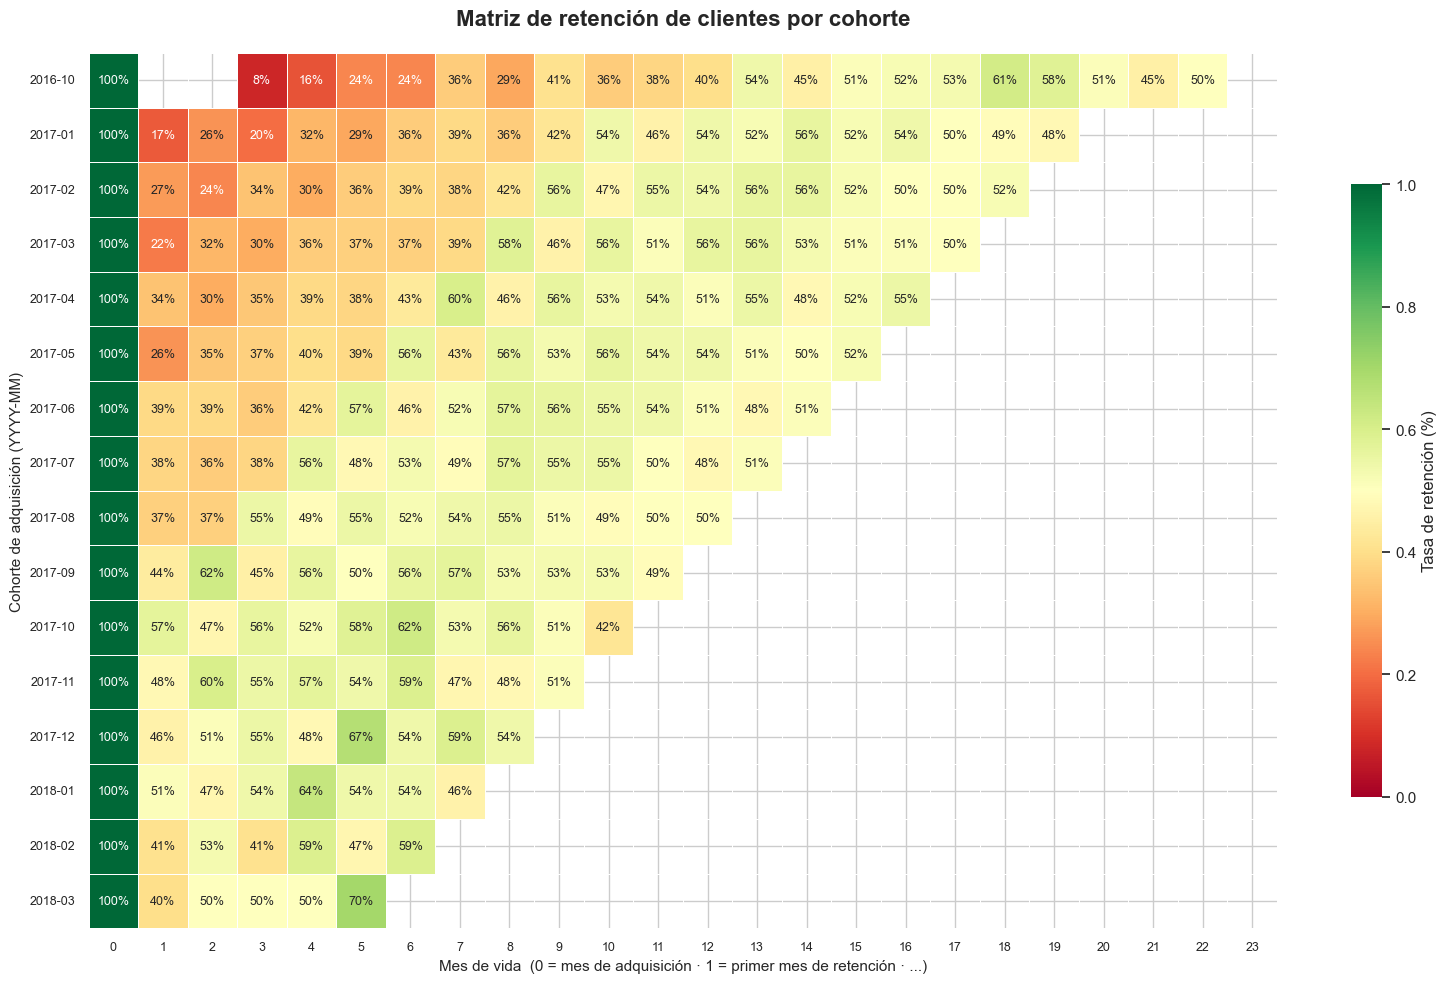

Guardado: ..\datos\04_procesados\cohortes_heatmap.png


In [25]:
# ── PASO 4: Visualización — Heatmap de retención ─────────────────────────────────
# El heatmap muestra qué porcentaje de clientes de cada cohorte volvió a comprar
# en cada mes de vida posterior.
# Rojo (0%) → Amarillo (50%) → Verde (100%)
# Las celdas enmascaradas (gris) indican meses sin datos: cohortes recientes que
# aún no completaron ese mes de vida dentro del período de observación del dataset.

OUTPUT_COHORTES_PNG = PROC_DIR / 'cohortes_heatmap.png'

# Máscara: True en las celdas donde no hay datos (NaN en la matriz de retención)
mascara_nan = matriz_retencion.isna()

# Anotaciones en formato "XX%"; las celdas sin datos quedan con string vacío.
# Se usa DataFrame.map() porque applymap() fue removido en pandas 3.x.
annot_matrix = matriz_retencion.map(
    lambda x: f'{x * 100:.0f}%' if pd.notna(x) else ''
)

fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    data=matriz_retencion.fillna(0),   # fillna(0) solo afecta el color; la máscara oculta esas celdas
    annot=annot_matrix,
    fmt='',                             # fmt='' porque annot ya contiene strings formateados
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    mask=mascara_nan,                   # Ocultar celdas sin datos para no confundirlas con 0%
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 9},
    cbar_kws={'label': 'Tasa de retención (%)', 'shrink': 0.7}
)

ax.set_title(
    'Matriz de retención de clientes por cohorte',
    fontsize=16,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Mes de vida  (0 = mes de adquisición · 1 = primer mes de retención · ...)', fontsize=11)
ax.set_ylabel('Cohorte de adquisición (YYYY-MM)', fontsize=11)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_COHORTES_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado: {OUTPUT_COHORTES_PNG}")

In [26]:
# ── PASO 5: Exportar para Power BI ───────────────────────────────────────────────
# Se generan dos archivos con distintas granularidades para cubrir diferentes
# necesidades de visualización en Power BI.
OUTPUT_COHORTES_LONG    = PROC_DIR / 'cohortes_retencion.csv'
OUTPUT_COHORTES_RESUMEN = PROC_DIR / 'cohortes_resumen.csv'

# ── Archivo 1: Formato largo (long format) ────────────────────────────────────────
# Una fila por (cohorte, mes_vida). Ideal para gráficos de líneas y tablas detalladas.
df_long = df_cohort_data[
    df_cohort_data['cohorte'].isin(cohortes_validas)
].copy()

# Agregar clientes_iniciales como columna de contexto (necesario para cálculos en Power BI)
clientes_ini_long = (
    df_cohort_data[df_cohort_data['mes_vida'] == 0][['cohorte', 'clientes_activos']]
    .rename(columns={'clientes_activos': 'clientes_iniciales'})
)
df_long = df_long.merge(clientes_ini_long, on='cohorte', how='left')
df_long['tasa_retencion'] = (
    df_long['clientes_activos'] / df_long['clientes_iniciales']
).round(4)

df_long = (
    df_long[['cohorte', 'mes_vida', 'clientes_activos', 'tasa_retencion', 'clientes_iniciales']]
    .sort_values(['cohorte', 'mes_vida'])
    .reset_index(drop=True)
)

df_long.to_csv(OUTPUT_COHORTES_LONG, encoding='utf-8-sig', index=False)
print(f"Exportado: {OUTPUT_COHORTES_LONG.name}  ({len(df_long):,} filas)")

# ── Archivo 2: Resumen por cohorte ────────────────────────────────────────────────
# Una fila por cohorte con métricas de retención consolidadas para tablas de resumen.

def get_retencion_mes(matriz, mes, idx):
    """Retorna la tasa de retención en el mes dado; retorna 0 si el mes no existe en el dataset."""
    if mes in matriz.columns:
        return matriz.loc[idx, mes].fillna(0).round(4)
    return pd.Series(0.0, index=idx, name=mes)

# Vida promedio: promedio de meses únicos en que cada cliente de la cohorte compró.
# Captura la extensión temporal de la lealtad antes de que el cliente abandone.
df_vida = (
    df_cohortes[df_cohortes['cohorte'].isin(cohortes_validas)]
    .groupby(['cohorte', 'ClienteID'])['mes_vida']
    .nunique()
    .reset_index()
    .rename(columns={'mes_vida': 'meses_activo'})
    .groupby('cohorte')['meses_activo']
    .mean()
    .round(2)
    .rename('vida_promedio')
)

df_resumen = pd.DataFrame({
    'cohorte'           : cohortes_validas.tolist(),
    'clientes_iniciales': matriz_clientes.loc[cohortes_validas, 0].astype(int).values,
    'retencion_mes_1'   : get_retencion_mes(matriz_retencion, 1, cohortes_validas).values,
    'retencion_mes_3'   : get_retencion_mes(matriz_retencion, 3, cohortes_validas).values,
    'retencion_mes_6'   : get_retencion_mes(matriz_retencion, 6, cohortes_validas).values,
})
df_resumen = df_resumen.merge(df_vida.reset_index(), on='cohorte', how='left')
df_resumen['vida_promedio'] = df_resumen['vida_promedio'].fillna(0)

df_resumen.to_csv(OUTPUT_COHORTES_RESUMEN, encoding='utf-8-sig', index=False)
print(f"Exportado: {OUTPUT_COHORTES_RESUMEN.name}  ({len(df_resumen):,} filas)")
print()
print("Preview cohortes_resumen.csv (primeras 5 filas):")
display(df_resumen.head())

Exportado: cohortes_retencion.csv  (216 filas)
Exportado: cohortes_resumen.csv  (16 filas)

Preview cohortes_resumen.csv (primeras 5 filas):


,cohorte,clientes_iniciales,retencion_mes_1,retencion_mes_3,retencion_mes_6,vida_promedio
0,2016-10,306,0.00,0.08,0.24,9.10
1,2017-01,845,0.17,0.20,0.36,8.93
2,2017-02,1502,0.27,0.34,0.39,9.01
3,2017-03,1814,0.22,0.30,0.37,8.61
4,2017-04,1260,0.34,0.35,0.43,8.48


In [27]:
# ── Verificación final del Bloque 8 ──────────────────────────────────────────────
sep = '=' * 60
print(sep)
print('  VERIFICACIÓN FINAL — Análisis de cohortes (Bloque 8)')
print(sep)

# 1. Rango de cohortes generadas
print(f'\n1. Cohortes generadas:')
print(f'   Primera: {cohortes_validas[0]}')
print(f'   Última:  {cohortes_validas[-1]}')
print(f'   Total:   {len(cohortes_validas)} cohortes válidas (≥ 10 clientes iniciales)')

# 2. Cohorte con mayor retención al mes 1
if 1 in matriz_retencion.columns:
    ret_mes1 = matriz_retencion[1].dropna()
    mejor_ret_1 = ret_mes1.idxmax()
    valor_ret_1 = ret_mes1.max()
    print(f'\n2. Cohorte con mayor retención al mes 1:')
    print(f'   {mejor_ret_1}  →  {valor_ret_1 * 100:.1f}%')
else:
    print('\n2. No hay datos suficientes para calcular retención al mes 1')

# 3. Cohorte con mayor cantidad de clientes iniciales
mejor_cohorte_ini = matriz_clientes[0].idxmax()
mejor_n_ini = int(matriz_clientes.loc[mejor_cohorte_ini, 0])
print(f'\n3. Cohorte con más clientes iniciales:')
print(f'   {mejor_cohorte_ini}  →  {mejor_n_ini:,} clientes')

# 4. Verificar que los archivos exportados existen y tienen contenido
print(f'\n4. Archivos exportados:')
for ruta in [OUTPUT_COHORTES_LONG, OUTPUT_COHORTES_RESUMEN, OUTPUT_COHORTES_PNG]:
    if ruta.exists():
        tam_kb = ruta.stat().st_size / 1024
        print(f'   ✓  {ruta.name:<45}  ({tam_kb:.1f} KB)')
    else:
        print(f'   ✗  {ruta.name} — NO generado')

print(f'\n{sep}')

  VERIFICACIÓN FINAL — Análisis de cohortes (Bloque 8)

1. Cohortes generadas:
   Primera: 2016-10
   Última:  2018-03
   Total:   16 cohortes válidas (≥ 10 clientes iniciales)

2. Cohorte con mayor retención al mes 1:
   2017-10  →  57.0%

3. Cohorte con más clientes iniciales:
   2017-03  →  1,814 clientes

4. Archivos exportados:
   ✓  cohortes_retencion.csv                         (5.5 KB)
   ✓  cohortes_resumen.csv                           (0.6 KB)
   ✓  cohortes_heatmap.png                           (292.1 KB)



---
## BLOQUE 9 — Exportar matriz de cohortes en formato ancho para Power BI

El análisis de cohortes del Bloque 8 generó los datos en **formato largo** (long format),
ideal para gráficos de líneas y cálculos en Power BI mediante DAX.

Sin embargo, para construir una **matriz de retención con formato condicional** en Power BI
(similar al heatmap del Bloque 8 pero interactivo), se necesita el formato **ancho** (wide format)
donde cada columna representa un mes de vida.

**Transformación aplicada:**
- Entrada: `cohortes_retencion.csv` — formato largo (cohorte, mes_vida, tasa_retencion)
- Salida: `cohortes_matriz_ancha.csv` — formato ancho (cohorte | mes_0 | mes_1 | ... | mes_12)

**Filtros aplicados:**
- Meses de vida: 0 a 12 inclusive (ventana de análisis de 1 año)
- Cohortes con `clientes_iniciales >= 50` (excluye cohortes estadísticamente poco representativas)

**Salida generada:**
| Archivo | Descripción |
|---|---|
| `cohortes_matriz_ancha.csv` | Matriz ancha de retención lista para importar en Power BI |

In [28]:
# ── BLOQUE 9: Leer cohortes_retencion.csv ya generado por el Bloque 8 ───────────
# Se lee directamente el archivo para que el bloque sea autocontenido y no dependa
# de variables en memoria que podrían no existir si el kernel fue reiniciado.
import pandas as pd
from pathlib import Path

RUTA_LONG  = Path(r'C:\Proyectos\integrador_carrera\datos\04_procesados\cohortes_retencion.csv')
RUTA_ANCHA = Path(r'C:\Proyectos\integrador_carrera\datos\04_procesados\cohortes_matriz_ancha.csv')

# Verificar que el archivo fuente existe antes de continuar
if not RUTA_LONG.exists():
    raise FileNotFoundError(
        f"Archivo no encontrado: {RUTA_LONG}\n"
        "Ejecutar el Bloque 8 para generar cohortes_retencion.csv"
    )

# Cargar el formato largo con encoding UTF-8-SIG (estándar del proyecto)
df_long = pd.read_csv(RUTA_LONG, encoding='utf-8-sig')
print(f"Filas cargadas desde cohortes_retencion.csv: {len(df_long):,}")
print(f"Columnas disponibles: {list(df_long.columns)}")
print()

# Filtrar meses de vida 0 a 12 (ventana anual estándar de análisis de retención)
# Más allá de mes 12 los datos son escasos porque pocas cohortes tienen tanto tiempo
df_filtrado = df_long[df_long['mes_vida'].between(0, 12)].copy()
print(f"Filas después de filtrar mes_vida 0-12: {len(df_filtrado):,}")

# Filtrar cohortes con clientes_iniciales >= 50 para excluir cohortes con
# muy pocos clientes, cuyos porcentajes de retención son estadísticamente ruidosos
df_filtrado = df_filtrado[df_filtrado['clientes_iniciales'] >= 50]
cohortes_incluidas = df_filtrado['cohorte'].nunique()
print(f"Filas después de filtrar clientes_iniciales >= 50: {len(df_filtrado):,}")
print(f"Cohortes incluidas: {cohortes_incluidas}")
print()

# Pivotear a formato ancho: una fila por cohorte, una columna por mes_vida
# aggfunc=mean para manejar automáticamente posibles duplicados en reprocesamiento
df_ancho = df_filtrado.pivot_table(
    index='cohorte',
    columns='mes_vida',
    values='tasa_retencion',
    aggfunc='mean'
)

# Renombrar columnas de enteros a strings (mes_0, mes_1, ... mes_12)
# para que Power BI las reconozca como nombres de campo sin conflicto con tipos numéricos
df_ancho.columns = [f'mes_{int(c)}' for c in df_ancho.columns]

# Rellenar NaN con 0: celdas vacías = meses no observados dentro del período del dataset
df_ancho = df_ancho.fillna(0)

# Redondear a 4 decimales (precisión suficiente para tasas de retención entre 0 y 1)
df_ancho = df_ancho.round(4)

# Resetear índice para que 'cohorte' quede como columna normal (no como índice)
# Power BI necesita que todas las dimensiones sean columnas planas en el CSV
df_ancho = df_ancho.reset_index()

# Ordenar por cohorte ascendente (orden cronológico)
df_ancho = df_ancho.sort_values('cohorte').reset_index(drop=True)

# Exportar con encoding UTF-8-SIG (BOM) para compatibilidad con Power BI en Windows
df_ancho.to_csv(RUTA_ANCHA, encoding='utf-8-sig', index=False)
print(f"Exportado: {RUTA_ANCHA}")
print()

# ── VERIFICACIÓN ─────────────────────────────────────────────────────────────────
print(f"Shape del DataFrame resultante: {df_ancho.shape}")
print()
print("Primeras 5 filas:")
display(df_ancho.head())
print()

# Confirmar que mes_0 tiene todos los valores = 1.0
# (mes de adquisición siempre tiene retención del 100% por definición)
if 'mes_0' in df_ancho.columns:
    valores_mes0 = df_ancho['mes_0'].unique()
    if len(valores_mes0) == 1 and valores_mes0[0] == 1.0:
        print("✓ mes_0: todos los valores son 1.0 (correcto — mes de adquisición = 100% retención)")
    else:
        valores_distintos = df_ancho[df_ancho['mes_0'] != 1.0]['mes_0'].tolist()
        print(f"ALERTA: mes_0 tiene valores distintos de 1.0: {valores_distintos}")
else:
    print("ALERTA: columna mes_0 no encontrada en el resultado")

# Confirmar que el CSV se guardó correctamente
if RUTA_ANCHA.exists():
    tam_kb = RUTA_ANCHA.stat().st_size / 1024
    df_check = pd.read_csv(RUTA_ANCHA, encoding='utf-8-sig')
    print(f"✓ CSV guardado correctamente: {RUTA_ANCHA.name}  ({tam_kb:.1f} KB)")
    print(f"  Filas: {len(df_check):,}  |  Columnas: {df_check.shape[1]}")
else:
    print(f"✗ Error: el archivo {RUTA_ANCHA.name} no se generó")

print()
print("Bloque 9 completado — cohortes_matriz_ancha.csv listo para Power BI")


Filas cargadas desde cohortes_retencion.csv: 216
Columnas disponibles: ['cohorte', 'mes_vida', 'clientes_activos', 'tasa_retencion', 'clientes_iniciales']

Filas después de filtrar mes_vida 0-12: 178
Filas después de filtrar clientes_iniciales >= 50: 165
Cohortes incluidas: 14

Exportado: C:\Proyectos\integrador_carrera\datos\04_procesados\cohortes_matriz_ancha.csv

Shape del DataFrame resultante: (14, 14)

Primeras 5 filas:


,cohorte,mes_0,mes_1,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12
0,2016-10,1.00,0.00,0.00,0.08,0.16,0.24,0.24,0.36,0.29,0.41,0.36,0.38,0.40
1,2017-01,1.00,0.17,0.26,0.20,0.32,0.29,0.36,0.39,0.36,0.42,0.54,0.46,0.54
2,2017-02,1.00,0.27,0.24,0.34,0.30,0.36,0.39,0.38,0.42,0.56,0.47,0.55,0.54
3,2017-03,1.00,0.22,0.32,0.30,0.36,0.37,0.37,0.39,0.58,0.46,0.56,0.51,0.56
4,2017-04,1.00,0.34,0.30,0.35,0.39,0.38,0.43,0.60,0.46,0.56,0.53,0.54,0.51



✓ mes_0: todos los valores son 1.0 (correcto — mes de adquisición = 100% retención)
✓ CSV guardado correctamente: cohortes_matriz_ancha.csv  (1.4 KB)
  Filas: 14  |  Columnas: 14

Bloque 9 completado — cohortes_matriz_ancha.csv listo para Power BI
